# Laboratory 3: Network Traffic Prediction (Supervised Learning)

Martin Demel

Department of Science, Technology, Engineering & Math, Houston Community College

6263-ITAI-4370-AI 5/6G Comm & ORAN Net-S10-14071

Tawanda Chiyangwa
June 22nd, 2026.


In this lab I build a supervised machine-learning model that predicts network traffic from historical data. I start with a synthetic year of hourly traffic that has daily, weekly, and business-hours patterns, add a few engineered features, and then train a Random Forest to predict the traffic level. In Part 1 I generate and explore the data, and in Part 2 I train the model and check how well it predicts on hours it has not seen.

## Part 1: Generate and explore the traffic data

Real telecom traffic rises and falls on a schedule — busier in the daytime, quieter at night and on weekends. I build a synthetic dataset with those patterns plus some random noise, then add engineered features that help a model learn: the traffic one hour ago, the traffic 24 hours ago, and a 7-day rolling average. The plots below show the patterns the model will learn from.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# Generate synthetic telecom traffic data
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='h')
n_samples = len(dates)

hour = dates.hour
day_of_week = dates.dayofweek
day_of_year = dates.dayofyear

# Base traffic with daily, weekly, and annual patterns plus noise
base_traffic = (
    50 +                                       # base level
    20 * np.sin(2 * np.pi * hour / 24) +        # daily pattern
    10 * np.sin(2 * np.pi * day_of_week / 7) +  # weekly pattern
    5 * np.sin(2 * np.pi * day_of_year / 365) + # annual pattern
    np.random.normal(0, 5, n_samples)           # noise
)

# Add a business-hours boost (weekday 09:00-17:00)
business_hours = (hour >= 9) & (hour <= 17) & (day_of_week < 5)
base_traffic += business_hours * 15

traffic_data = pd.DataFrame({
    'timestamp': dates,
    'hour': hour,
    'day_of_week': day_of_week,
    'is_weekend': day_of_week >= 5,
    'is_business_hours': business_hours,
    'traffic_gbps': np.maximum(base_traffic, 0)   # keep non-negative
})

# Feature engineering: lagged values and a rolling average
traffic_data['traffic_lag_1h'] = traffic_data['traffic_gbps'].shift(1)
traffic_data['traffic_lag_24h'] = traffic_data['traffic_gbps'].shift(24)
traffic_data['traffic_rolling_7d'] = traffic_data['traffic_gbps'].rolling(
    window=24*7, center=True).mean()

traffic_data = traffic_data.dropna()

print("Dataset shape:", traffic_data.shape)
print("\nFirst few rows:")
print(traffic_data.head())

Dataset shape: (8570, 9)

First few rows:
             timestamp  hour  day_of_week  is_weekend  is_business_hours  \
84 2023-01-04 12:00:00    12            2       False               True   
85 2023-01-04 13:00:00    13            2       False               True   
86 2023-01-04 14:00:00    14            2       False               True   
87 2023-01-04 15:00:00    15            2       False               True   
88 2023-01-04 16:00:00    16            2       False               True   

    traffic_gbps  traffic_lag_1h  traffic_lag_24h  traffic_rolling_7d  
84     71.050823       77.678321        70.680542           54.166101  
85     67.408125       71.050823        66.971737           54.147588  
86     69.670302       67.408125        57.544738           54.132844  
87     62.594911       69.670302        52.953244           54.090667  
88     55.123982       62.594911        59.818534           54.024632  


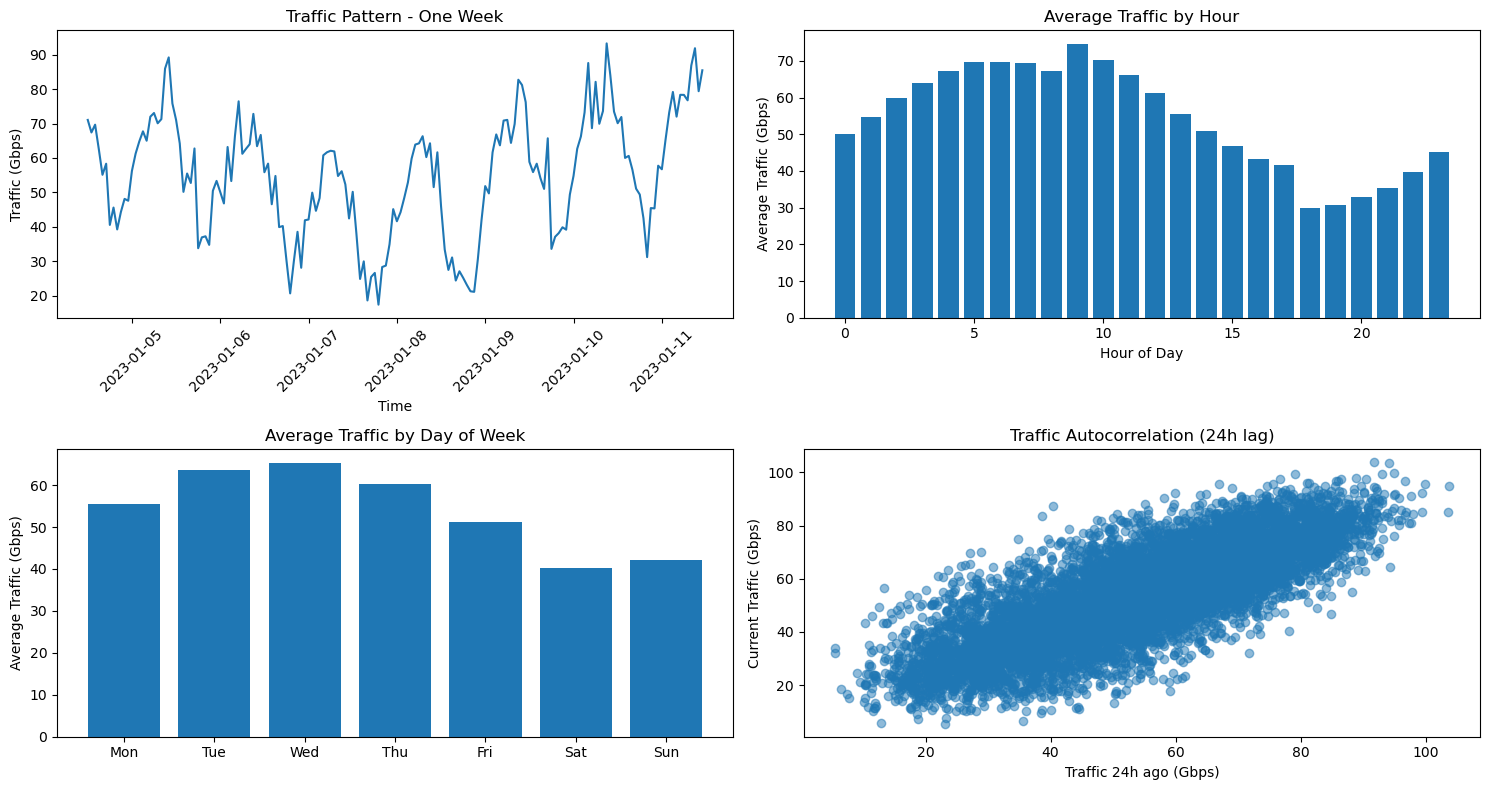

In [2]:
# Visualize the traffic patterns
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.plot(traffic_data['timestamp'][:24*7], traffic_data['traffic_gbps'][:24*7])
plt.title('Traffic Pattern - One Week')
plt.xlabel('Time'); plt.ylabel('Traffic (Gbps)')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
hourly_avg = traffic_data.groupby('hour')['traffic_gbps'].mean()
plt.bar(hourly_avg.index, hourly_avg.values)
plt.title('Average Traffic by Hour')
plt.xlabel('Hour of Day'); plt.ylabel('Average Traffic (Gbps)')

plt.subplot(2, 2, 3)
daily_avg = traffic_data.groupby('day_of_week')['traffic_gbps'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.bar(days, daily_avg.values)
plt.title('Average Traffic by Day of Week')
plt.ylabel('Average Traffic (Gbps)')

plt.subplot(2, 2, 4)
plt.scatter(traffic_data['traffic_lag_24h'], traffic_data['traffic_gbps'], alpha=0.5)
plt.title('Traffic Autocorrelation (24h lag)')
plt.xlabel('Traffic 24h ago (Gbps)'); plt.ylabel('Current Traffic (Gbps)')

plt.tight_layout()
plt.show()

The one-week plot shows the daily rise and fall, the hourly chart peaks during the working day, and the day-of-week chart is higher on weekdays than on weekends. The 24-hour lag scatter forms a clear positive diagonal, which means today's traffic is closely related to the traffic one day earlier — a strong, learnable signal.

## Part 2: Train and evaluate the model

I use the engineered features to predict the current traffic level with a Random Forest, an ensemble of decision trees that works well on this kind of tabular data. The data is split in time order (no shuffling), so the model is tested on later hours it has never seen — the same situation as forecasting the future. I score it with mean squared error (MSE) and R², and check which features matter most.

In [3]:
# Features and target
feature_columns = [
    'hour', 'day_of_week', 'is_weekend', 'is_business_hours',
    'traffic_lag_1h', 'traffic_lag_24h', 'traffic_rolling_7d'
]
X = traffic_data[feature_columns]
y = traffic_data['traffic_gbps']

# Split in time order (no shuffle): test set = later, unseen hours
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False)

# Train the Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

print("Model Performance:")
print(f"Training MSE: {mean_squared_error(y_train, y_pred_train):.2f}")
print(f"Testing MSE:  {mean_squared_error(y_test, y_pred_test):.2f}")
print(f"Training R2:  {r2_score(y_train, y_pred_train):.3f}")
print(f"Testing R2:   {r2_score(y_test, y_pred_test):.3f}")

# Which features the model relied on most
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance.to_string(index=False))

Model Performance:
Training MSE: 17.58
Testing MSE:  34.65
Training R2:  0.946
Testing R2:   0.893

Feature Importance:
           feature  importance
    traffic_lag_1h    0.815707
              hour    0.077714
   traffic_lag_24h    0.035666
       day_of_week    0.027890
traffic_rolling_7d    0.023436
 is_business_hours    0.017467
        is_weekend    0.002119


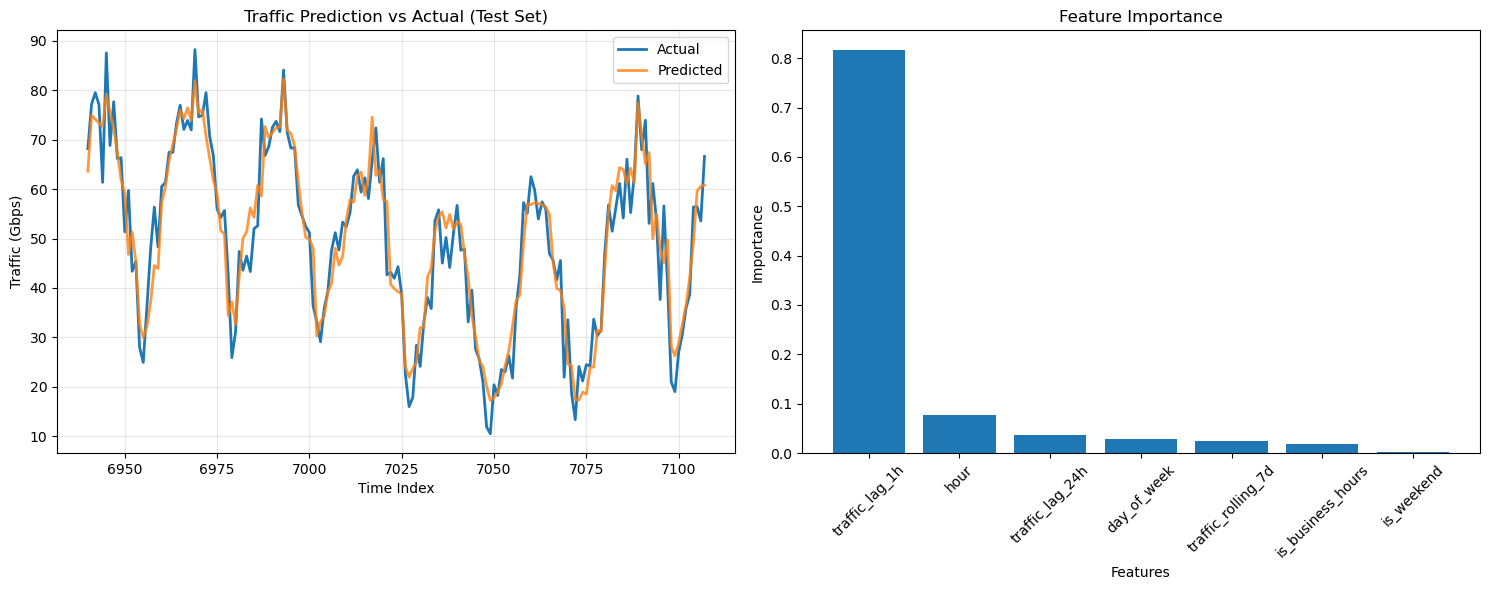

In [4]:
plt.figure(figsize=(15, 6))
test_indices = X_test.index[:168]   # one week of test data

plt.subplot(1, 2, 1)
plt.plot(test_indices, y_test.loc[test_indices], label='Actual', linewidth=2)
plt.plot(test_indices, y_pred_test[:len(test_indices)], label='Predicted',
         linewidth=2, alpha=0.8)
plt.title('Traffic Prediction vs Actual (Test Set)')
plt.xlabel('Time Index'); plt.ylabel('Traffic (Gbps)')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.title('Feature Importance')
plt.xlabel('Features'); plt.ylabel('Importance')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The predicted line tracks the actual traffic closely on the unseen test week, with a test R² of about 0.89 — the model explains roughly 89% of the variation in traffic. The feature-importance chart shows the traffic one hour ago is by far the strongest predictor, with the hour of day and the 24-hour lag adding smaller contributions. This matches Part 1: recent history and time of day carry most of the signal.

## Summary

I built a supervised model that predicts hourly network traffic from its own recent history and a few simple time features. Trained on the first part of the year and tested on later, unseen hours, the Random Forest follows the real traffic well (test R² ≈ 0.89), and the most useful feature is the traffic from the previous hour.

This is the kind of prediction that drives an intelligent RAN: forecasting demand lets a scheduler or a RIC application allocate radio resources before congestion happens. That is the link to the companion **Assignment 3**, which covers AI/ML in the RAN, Self-Organizing Networks, and the RAN Intelligent Controller.